# HKM Ranking From Top Atoms

This notebook owns the full workflow. The `.py` file only stores reusable functions.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from matplotlib.ticker import ScalarFormatter

from hkm_top_atoms_ranked import (
    ATOM_METRICS_CSV,
    ATOMS_JSONL,
    HKM_TEMPLATE_DIR,
    LOGIC_NAMES,
    TEST_IPS,
    TOP_INTERVALS_CSV,
    TRAIN_IPS,
    build_atom_match_infos,
    build_output_dir,
    count_label_patients,
    enumerate_top_hkms_by_length,
    estimate_total_hkm_count_from_work_items,
    load_samples,
    load_selected_atoms,
    load_templates,
    load_top_intervals_from_csv,
    plot_saved_hkm_curves,
    write_final_hkm_outputs,
)


In [4]:
# Search settings
TOP_ATOMS_PER_FEATURE = 30
TOP_HKMS_PER_LENGTH = 5000
CURVE_TOP_N = None
NUM_WORKERS = 28
CHECKPOINT_EVERY_HKMS = 10000
LENGTHS = (4, 3, 2)

# Output settings
OUTPUT_ROOT = Path(r"D:\\PythonProject\\paper\\hkm_top_atoms_ranked_outputs")
OUTPUT_DIR = build_output_dir(
    top_atoms_per_feature=TOP_ATOMS_PER_FEATURE,
    top_hkms_per_length=TOP_HKMS_PER_LENGTH,
    output_root=OUTPUT_ROOT,
)

# Plot-only input: this can be pointed to any finished HKM output directory.
PLOT_OUTPUT_DIR = OUTPUT_DIR

# Plot settings for per-length saved curve regeneration
PLOT_CONFIG = {
    'figsize': (8, 5),
    'dpi': 150,
    'train_label0_color': 'tab:blue',
    'train_label1_color': 'tab:blue',
    'test_label0_color': 'tab:orange',
    'test_label1_color': 'tab:orange',
    'train_label0_linestyle': '-',
    'train_label1_linestyle': '--',
    'test_label0_linestyle': '-',
    'test_label1_linestyle': '--',
    'train_label0_label': 'train label0',
    'train_label1_label': 'train label1',
    'test_label0_label': 'test label0',
    'test_label1_label': 'test label1',
    'xlabel': 'Top N HKMs',
    'ylabel': 'Covered patient ratio',
    'title_template': '{logic_name} - HKM Length {length} Coverage Curve',
    'ylim': (0.0, 1.0),
    'grid': True,
    'grid_alpha': 0.3,
    'legend': True,
}

# Readable combined-figure settings
COMBINED_CURVE_DIRNAME = 'combined_curve_figures_readable'
FORCE_REGENERATE_SAVED_CURVES = False
FORCE_REGENERATE_COMBINED_FIGURES = False
NONLINEAR_X_TICKS = [1, 2, 3, 5, 10, 30, 100, 300, 1000, 3000, 5000]
ALL_LOGIC_COMBINED_BASENAME = 'hkm_curve_all_logics_combined'
COMBINED_PLOT_CONFIG = {
    'figsize': (16.0, 14.5),
    'dpi': 220,
    'xscale': 'log',
    'grid': True,
    'grid_alpha': 0.28,
    'ylim': (0.0, 1.0),
    'line_width': 2.0,
    'title_fontsize': 14,
    'axis_label_fontsize': 12,
    'tick_labelsize': 10,
    'legend_fontsize': 11,
    'subtitle_fontsize': 11,
    'suptitle_y': 0.992,
    'legend_bbox_y': 0.974,
    'tight_layout_rect': (0.055, 0.05, 0.98, 0.955),
    'h_pad': 1.3,
    'w_pad': 1.1,
}

PLOT_OUTPUT_DIR


WindowsPath('D:/PythonProject/paper/hkm_top_atoms_ranked_outputs/atoms_per_feature_30_top_hkms_5000')

Load atoms, train/test data, top intervals, and estimate the HKM search size before launching enumeration.

In [5]:
atoms = load_selected_atoms(ATOMS_JSONL, ATOM_METRICS_CSV, TOP_ATOMS_PER_FEATURE)
train_samples = load_samples(TRAIN_IPS)
test_samples = load_samples(TEST_IPS)
train_totals = count_label_patients(train_samples)
test_totals = count_label_patients(test_samples)
top_intervals = load_top_intervals_from_csv(TOP_INTERVALS_CSV)
templates_by_length = load_templates(HKM_TEMPLATE_DIR, LENGTHS)
atom_infos, train_totals_from_bits, test_totals_from_bits = build_atom_match_infos(
    atoms,
    train_samples,
    test_samples,
    top_intervals,
)
assert train_totals == train_totals_from_bits
assert test_totals == test_totals_from_bits
estimated_total_hkms = estimate_total_hkm_count_from_work_items(atom_infos, templates_by_length, LENGTHS)

print(f"Selected atoms: {len(atoms)}")
print(f"Train patient totals: label0={train_totals[0]}, label1={train_totals[1]}")
print(f"Test patient totals: label0={test_totals[0]}, label1={test_totals[1]}")
print(f"Estimated total HKMs to evaluate: {estimated_total_hkms}")

Selected atoms: 273
Train patient totals: label0=864, label1=3630
Test patient totals: label0=200, label1=925
Estimated total HKMs to evaluate: 3086234460


Enumerate HKMs with checkpointing, apply support-set equality dedup online, keep top-5000 HKMs for each retention logic, and write final outputs.

In [15]:
top_records_by_logic_by_length, processed_counts = enumerate_top_hkms_by_length(
    atom_infos=atom_infos,
    templates_by_length=templates_by_length,
    top_hkms_per_length=TOP_HKMS_PER_LENGTH,
    lengths=LENGTHS,
    train_totals=train_totals,
    test_totals=test_totals,
    output_dir=OUTPUT_DIR,
    num_workers=NUM_WORKERS,
    checkpoint_every_hkms=CHECKPOINT_EVERY_HKMS,
)

write_final_hkm_outputs(
    output_dir=OUTPUT_DIR,
    top_records_by_logic_by_length=top_records_by_logic_by_length,
    processed_counts=processed_counts,
    top_atoms_per_feature=TOP_ATOMS_PER_FEATURE,
    top_hkms_per_length=TOP_HKMS_PER_LENGTH,
    curve_top_n=CURVE_TOP_N,
    train_totals=train_totals,
    test_totals=test_totals,
    num_workers=NUM_WORKERS,
    lengths=LENGTHS,
    checkpoint_every_hkms=CHECKPOINT_EVERY_HKMS,
)

summary = {
    "selected_atom_count": len(atoms),
    "estimated_total_hkms": estimated_total_hkms,
    "processed_counts": processed_counts,
    "retained_counts": {
        logic_name: {
            length: len(top_records_by_logic_by_length[logic_name][length])
            for length in LENGTHS
        }
        for logic_name in LOGIC_NAMES
    },
}
summary

Processing length 4 with 210 pending chunks and 0 completed chunks using 28 workers
Completed length 4 chunk 1/210: len4__admissions__albumin__ldh__plt (processed 2268000 HKMs)
Completed length 4 chunk 2/210: len4__admissions__albumin__ecog__ldh (processed 2268000 HKMs)
Completed length 4 chunk 3/210: len4__admissions__albumin__ecog__plt (processed 2268000 HKMs)
Completed length 4 chunk 4/210: len4__admissions__albumin__creatinine__ecog (processed 2268000 HKMs)
Completed length 4 chunk 5/210: len4__admissions__albumin__creatinine__urea (processed 2268000 HKMs)
Completed length 4 chunk 6/210: len4__admissions__albumin__ast__urea (processed 2268000 HKMs)
Completed length 4 chunk 7/210: len4__admissions__albumin__ecog__urea (processed 2268000 HKMs)
Completed length 4 chunk 8/210: len4__admissions__albumin__creatinine__plt (processed 2268000 HKMs)
Completed length 4 chunk 9/210: len4__admissions__albumin__ldh__total_bilirubin (processed 2268000 HKMs)
Completed length 4 chunk 10/210: len4__

{'selected_atom_count': 273,
 'estimated_total_hkms': 3086234460,
 'processed_counts': {4: 3048192000, 3: 37843200, 2: 199260},
 'retained_counts': {'precision0': {4: 5000, 3: 5000, 2: 5000},
  'precision0_plus_recall0': {4: 5000, 3: 5000, 2: 5000}}}

Redraw the saved curve files directly from the finished output folder.

This section is plot-only: it reloads everything it needs from `PLOT_OUTPUT_DIR`, so it can be run independently after HKM enumeration has finished.


In [6]:
def load_plot_context_from_output_dir(output_dir: Path) -> dict:
    summary_path = output_dir / 'run_summary.json'
    if not summary_path.exists():
        raise FileNotFoundError(f'Missing summary file: {summary_path}')
    summary = json.loads(summary_path.read_text(encoding='utf-8'))
    return {
        'summary': summary,
        'lengths': tuple(int(length) for length in summary.get('lengths', [])),
        'logic_names': tuple(summary.get('logic_names', list(LOGIC_NAMES))),
        'curve_top_n': summary.get('curve_top_n'),
        'combined_curve_dir': output_dir / COMBINED_CURVE_DIRNAME,
        'top_hkms_per_length': int(summary.get('top_hkms_per_length', TOP_HKMS_PER_LENGTH)),
    }


def curve_file_paths(output_dir: Path, logic_name: str, length: int, curve_suffix: str):
    return {
        'csv': output_dir / f'hkm_curve_{logic_name}_len{length}_{curve_suffix}.csv',
        'png': output_dir / f'hkm_curve_{logic_name}_len{length}_{curve_suffix}.png',
    }


def combined_figure_path(combined_curve_dir: Path, logic_name: str, curve_suffix: str) -> Path:
    return combined_curve_dir / f'hkm_curve_{logic_name}_combined_{curve_suffix}.png'


def load_saved_curve_df(output_dir: Path, logic_name: str, length: int, curve_suffix: str) -> pd.DataFrame:
    path = curve_file_paths(output_dir, logic_name, length, curve_suffix)['csv']
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def ensure_saved_curve_files(output_dir: Path, lengths, logic_names, curve_suffix: str, curve_top_n, force: bool = False):
    required = []
    for logic_name in logic_names:
        for length in lengths:
            required.append(curve_file_paths(output_dir, logic_name, length, curve_suffix)['csv'])
    if (not force) and all(path.exists() for path in required):
        return required
    plot_saved_hkm_curves(
        output_dir=output_dir,
        curve_top_n=curve_top_n,
        plot_config=PLOT_CONFIG,
    )
    return required


def all_logic_combined_figure_path(combined_curve_dir: Path, curve_suffix: str) -> Path:
    return combined_curve_dir / f'{ALL_LOGIC_COMBINED_BASENAME}_{curve_suffix}.png'


def save_all_logic_combined_curve_figure(output_dir: Path, logic_names, lengths, curve_suffix: str, combined_curve_dir: Path, config: dict, force: bool = False) -> Path:
    combined_curve_dir.mkdir(parents=True, exist_ok=True)
    out_path = all_logic_combined_figure_path(combined_curve_dir, curve_suffix)
    if out_path.exists() and not force:
        return out_path

    fig, axes = plt.subplots(len(lengths), len(logic_names), figsize=config['figsize'], dpi=config['dpi'], sharex=True, sharey=True)
    if len(lengths) == 1 and len(logic_names) == 1:
        axes = [[axes]]
    elif len(lengths) == 1:
        axes = [axes]
    elif len(logic_names) == 1:
        axes = [[ax] for ax in axes]

    for row_idx, length in enumerate(lengths):
        for col_idx, logic_name in enumerate(logic_names):
            ax = axes[row_idx][col_idx]
            df = load_saved_curve_df(output_dir, logic_name, length, curve_suffix)
            x = df['top_n_hkms']
            ax.plot(x, df['train_label0_ratio'], color=PLOT_CONFIG['train_label0_color'], linestyle=PLOT_CONFIG['train_label0_linestyle'], linewidth=config['line_width'], label=PLOT_CONFIG['train_label0_label'])
            ax.plot(x, df['train_label1_ratio'], color=PLOT_CONFIG['train_label1_color'], linestyle=PLOT_CONFIG['train_label1_linestyle'], linewidth=config['line_width'], label=PLOT_CONFIG['train_label1_label'])
            ax.plot(x, df['test_label0_ratio'], color=PLOT_CONFIG['test_label0_color'], linestyle=PLOT_CONFIG['test_label0_linestyle'], linewidth=config['line_width'], label=PLOT_CONFIG['test_label0_label'])
            ax.plot(x, df['test_label1_ratio'], color=PLOT_CONFIG['test_label1_color'], linestyle=PLOT_CONFIG['test_label1_linestyle'], linewidth=config['line_width'], label=PLOT_CONFIG['test_label1_label'])

            ax.set_xscale(config['xscale'])
            max_x = int(df['top_n_hkms'].max())
            ticks = [tick for tick in NONLINEAR_X_TICKS if tick <= max_x]
            if max_x not in ticks:
                ticks.append(max_x)
            ax.set_xticks(ticks)
            ax.set_xticklabels([f'{tick:,}' for tick in ticks], fontsize=config['tick_labelsize'])
            ax.xaxis.set_major_formatter(ScalarFormatter())
            ax.minorticks_off()
            ax.tick_params(axis='y', labelsize=config['tick_labelsize'])
            ax.set_ylim(*config['ylim'])
            if config.get('grid', False):
                ax.grid(True, alpha=config.get('grid_alpha', 0.3))
            title_logic = 'precision0_recall0_mean' if logic_name == 'precision0_plus_recall0' else logic_name
            ax.set_title(f'{title_logic} | Length {length}', fontsize=config['title_fontsize'], pad=8)
            if col_idx == 0:
                ax.set_ylabel('Covered-patient ratio', fontsize=config['axis_label_fontsize'])
            if row_idx == len(lengths) - 1:
                ax.set_xlabel('Top N HKMs included in the cumulative classifier (log scale)', fontsize=config['axis_label_fontsize'])

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.suptitle('HKM combined coverage curves', y=config.get('suptitle_y', 0.992), fontsize=17)
    fig.legend(
        handles,
        labels,
        loc='upper center',
        ncol=4,
        frameon=False,
        fontsize=config['legend_fontsize'],
        bbox_to_anchor=(0.5, config.get('legend_bbox_y', 0.974)),
        handlelength=2.8,
        columnspacing=1.6,
    )
    fig.tight_layout(
        rect=config.get('tight_layout_rect', (0.055, 0.05, 0.98, 0.955)),
        h_pad=config.get('h_pad', 1.3),
        w_pad=config.get('w_pad', 1.1),
    )
    fig.savefig(out_path, bbox_inches='tight')
    plt.close(fig)
    return out_path

plot_context = load_plot_context_from_output_dir(PLOT_OUTPUT_DIR)
PLOT_LENGTHS = plot_context['lengths']
PLOT_LOGIC_NAMES = plot_context['logic_names']
PLOT_CURVE_TOP_N = plot_context['curve_top_n']
PLOT_CURVE_SUFFIX = 'all' if PLOT_CURVE_TOP_N is None else f'top{PLOT_CURVE_TOP_N}'
COMBINED_CURVE_DIR = plot_context['combined_curve_dir']

ensure_saved_curve_files(
    output_dir=PLOT_OUTPUT_DIR,
    lengths=PLOT_LENGTHS,
    logic_names=PLOT_LOGIC_NAMES,
    curve_suffix=PLOT_CURVE_SUFFIX,
    curve_top_n=PLOT_CURVE_TOP_N,
    force=FORCE_REGENERATE_SAVED_CURVES,
)

combined_curve_path = save_all_logic_combined_curve_figure(
    PLOT_OUTPUT_DIR,
    PLOT_LOGIC_NAMES,
    PLOT_LENGTHS,
    PLOT_CURVE_SUFFIX,
    COMBINED_CURVE_DIR,
    COMBINED_PLOT_CONFIG,
    force=FORCE_REGENERATE_COMBINED_FIGURES,
)
combined_curve_path


{'precision0': WindowsPath('D:/PythonProject/paper/hkm_top_atoms_ranked_outputs/atoms_per_feature_30_top_hkms_5000/combined_curve_figures/hkm_curve_precision0_combined_all.png'),
 'precision0_plus_recall0': WindowsPath('D:/PythonProject/paper/hkm_top_atoms_ranked_outputs/atoms_per_feature_30_top_hkms_5000/combined_curve_figures/hkm_curve_precision0_plus_recall0_combined_all.png')}

In [7]:
summary_path = OUTPUT_DIR / "run_summary.json"
summary_from_disk = json.loads(summary_path.read_text(encoding="utf-8"))
summary_from_disk

{'top_atoms_per_feature': 30,
 'top_hkms_per_length': 5000,
 'curve_top_n': None,
 'num_workers': 28,
 'lengths': [4, 3, 2],
 'logic_names': ['precision0', 'precision0_plus_recall0'],
 'checkpoint_every_hkms': 10000,
 'processed_hkm_counts_by_length': {'4': 3048192000,
  '3': 37843200,
  '2': 199260},
 'retained_hkm_counts_by_logic_and_length': {'precision0': {'4': 5000,
   '3': 5000,
   '2': 5000},
  'precision0_plus_recall0': {'4': 5000, '3': 5000, '2': 5000}},
 'train_totals': {'label0': 864, 'label1': 3630},
 'test_totals': {'label0': 200, 'label1': 925}}

In [8]:
pd.DataFrame(
    [
        {
            "logic": logic_name,
            "length": length,
            "processed_hkms": summary_from_disk["processed_hkm_counts_by_length"][str(length)],
            "retained_hkms": summary_from_disk["retained_hkm_counts_by_logic_and_length"][logic_name][str(length)],
        }
        for logic_name in LOGIC_NAMES
        for length in LENGTHS
    ]
)

,logic,length,processed_hkms,retained_hkms
0,precision0,4,3048192000,5000
1,precision0,3,37843200,5000
2,precision0,2,199260,5000
3,precision0_plus_recall0,4,3048192000,5000
4,precision0_plus_recall0,3,37843200,5000
5,precision0_plus_recall0,2,199260,5000


Precision-only retention tables.

In [9]:
for length in LENGTHS:
    print(f"\n===== {LOGIC_NAMES[0]} | Length {length} =====")
    metrics_path = OUTPUT_DIR / f"hkm_metrics_{LOGIC_NAMES[0]}_len{length}_top{TOP_HKMS_PER_LENGTH}.csv"
    display(pd.read_csv(metrics_path).head(20))


===== precision0 | Length 4 =====


,rank,hkm_id,formula_id,length,formula,atom_ids,features,source_pattern_ids,train_dedup_support0_excluding_sources,train_dedup_support1_excluding_sources,...,train_dedup_precision1_excluding_sources,train_dedup_recall0_excluding_sources,train_dedup_recall1_excluding_sources,train_precision0_recall0_mean,test_support0,test_support1,test_precision0,test_precision1,test_recall0,test_recall1
0,1,len4__admissions__albumin__ecog__plt__combo615...,len4_0004,4,(((x1 OR x2) OR x3) AND x4),"[""atom_32"", ""atom_125939"", ""atom_22550"", ""atom...","[""admissions"", ""albumin"", ""ecog"", ""plt""]","[""pattern_5"", ""pattern_29785"", ""pattern_4949"",...",1,0,...,0.000000,0.001157,0.000000,0.500579,1,2,0.333333,0.666667,0.005,0.002162
1,2,len4__admissions__albumin__creatinine__ecog__c...,len4_0005,4,((x1 OR x2) AND (x3 OR x4)),"[""atom_2176"", ""atom_151746"", ""atom_210988"", ""a...","[""admissions"", ""albumin"", ""creatinine"", ""ecog""]","[""pattern_462"", ""pattern_36400"", ""pattern_5194...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,1,0.000000,1.000000,0.000,0.001081
2,3,len4__admissions__albumin__ast__creatinine__co...,len4_0005,4,((x1 OR x2) AND (x3 OR x4)),"[""atom_32"", ""atom_112885"", ""atom_105487"", ""ato...","[""admissions"", ""albumin"", ""ast"", ""creatinine""]","[""pattern_5"", ""pattern_26428"", ""pattern_24571""...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,1,0.000000,1.000000,0.000,0.001081
3,4,len4__admissions__albumin__ast__neutrophils__c...,len4_0005,4,((x1 OR x2) AND (x3 OR x4)),"[""atom_32"", ""atom_123108"", ""atom_142872"", ""ato...","[""admissions"", ""albumin"", ""ast"", ""neutrophils""]","[""pattern_5"", ""pattern_29068"", ""pattern_34143""...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,0,0.000000,0.000000,0.000,0.000000
4,5,len4__admissions__albumin__creatinine__ldh__co...,len4_0005,4,((x1 OR x2) AND (x3 OR x4)),"[""atom_32"", ""atom_189841"", ""atom_280597"", ""ato...","[""admissions"", ""albumin"", ""creatinine"", ""ldh""]","[""pattern_5"", ""pattern_46312"", ""pattern_70908""...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,0,0.000000,0.000000,0.000,0.000000
5,6,len4__admissions__albumin__ast__ecog__combo317...,len4_0005,4,((x1 OR x2) AND (x3 OR x4)),"[""atom_3090"", ""atom_123108"", ""atom_185463"", ""a...","[""admissions"", ""albumin"", ""ast"", ""ecog""]","[""pattern_661"", ""pattern_29068"", ""pattern_4514...",1,0,...,0.000000,0.001157,0.000000,0.500579,1,0,1.000000,0.000000,0.005,0.000000
6,7,len4__admissions__albumin__ast__plt__combo5413...,len4_0026,4,(((x1 OR x2) AND NOT x3) AND x4),"[""atom_32"", ""atom_101423"", ""atom_145295"", ""ato...","[""admissions"", ""albumin"", ""ast"", ""plt""]","[""pattern_5"", ""pattern_23579"", ""pattern_34767""...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,0,0.000000,0.000000,0.000,0.000000
7,8,len4__admissions__creatinine__ecog__ldh__combo...,len4_0009,4,((x1 AND x2) OR (x3 AND x4)),"[""atom_32"", ""atom_151225"", ""atom_117737"", ""ato...","[""admissions"", ""creatinine"", ""ecog"", ""ldh""]","[""pattern_5"", ""pattern_36262"", ""pattern_27703""...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,0,0.000000,0.000000,0.000,0.000000
8,9,len4__admissions__creatinine__ecog__ldh__combo...,len4_0009,4,((x1 AND x2) OR (x3 AND x4)),"[""atom_32"", ""atom_282289"", ""atom_117737"", ""ato...","[""admissions"", ""creatinine"", ""ecog"", ""ldh""]","[""pattern_5"", ""pattern_71385"", ""pattern_27703""...",1,0,...,0.000000,0.001157,0.000000,0.500579,0,0,0.000000,0.000000,0.000,0.000000
9,10,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_123108"", ""atom_101976"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_23723""...",322,26,...,0.074713,0.372685,0.007163,0.648986,66,5,0.929577,0.070423,0.330,0.005405



===== precision0 | Length 3 =====


,rank,hkm_id,formula_id,length,formula,atom_ids,features,source_pattern_ids,train_dedup_support0_excluding_sources,train_dedup_support1_excluding_sources,...,train_dedup_precision1_excluding_sources,train_dedup_recall0_excluding_sources,train_dedup_recall1_excluding_sources,train_precision0_recall0_mean,test_support0,test_support1,test_precision0,test_precision1,test_recall0,test_recall1
0,1,len3__admissions__albumin__plt__combo2047__tmpl2,len3_0003,3,((x1 OR x2) AND x3),"[""atom_32"", ""atom_125939"", ""atom_174955""]","[""admissions"", ""albumin"", ""plt""]","[""pattern_5"", ""pattern_29785"", ""pattern_42395""]",1,0,...,0.000000,0.001157,0.000000,0.500579,1,2,0.333333,0.666667,0.005,0.002162
1,2,len3__admissions__albumin__creatinine__combo10...,len3_0003,3,((x1 OR x2) AND x3),"[""atom_2176"", ""atom_112885"", ""atom_210988""]","[""admissions"", ""albumin"", ""creatinine""]","[""pattern_462"", ""pattern_26428"", ""pattern_51949""]",1,0,...,0.000000,0.001157,0.000000,0.500579,0,1,0.000000,1.000000,0.000,0.001081
2,3,len3__admissions__albumin__creatinine__combo19...,len3_0003,3,((x1 OR x2) AND x3),"[""atom_32"", ""atom_112885"", ""atom_7574""]","[""admissions"", ""albumin"", ""creatinine""]","[""pattern_5"", ""pattern_26428"", ""pattern_1642""]",1,0,...,0.000000,0.001157,0.000000,0.500579,0,1,0.000000,1.000000,0.000,0.001081
3,4,len3__admissions__albumin__ecog__combo2545__tmpl8,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_18892"", ""atom_62210""]","[""admissions"", ""albumin"", ""ecog""]","[""pattern_5"", ""pattern_4110"", ""pattern_14104""]",321,22,...,0.064140,0.371528,0.006061,0.653694,66,4,0.942857,0.057143,0.330,0.004324
4,5,len3__admissions__albumin__ecog__combo1975__tmpl8,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_123108"", ""atom_62210""]","[""admissions"", ""albumin"", ""ecog""]","[""pattern_5"", ""pattern_29068"", ""pattern_14104""]",320,22,...,0.064327,0.370370,0.006061,0.653021,66,4,0.942857,0.057143,0.330,0.004324
5,6,len3__admissions__albumin__creatinine__combo25...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_18892"", ""atom_168647""]","[""admissions"", ""albumin"", ""creatinine""]","[""pattern_5"", ""pattern_4110"", ""pattern_40773""]",323,23,...,0.066474,0.373843,0.006336,0.653684,66,4,0.942857,0.057143,0.330,0.004324
6,7,len3__admissions__neutrophils__plt__combo1980_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_106138"", ""atom_100716""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_24730"", ""pattern_23399""]",323,23,...,0.066474,0.373843,0.006336,0.653684,66,4,0.942857,0.057143,0.330,0.004324
7,8,len3__admissions__neutrophils__plt__combo2520_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_118280"", ""atom_100716""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_27842"", ""pattern_23399""]",323,23,...,0.066474,0.373843,0.006336,0.653684,66,5,0.929577,0.070423,0.330,0.005405
8,9,len3__admissions__neutrophils__plt__combo2525_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_118280"", ""atom_153897""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_27842"", ""pattern_36960""]",323,23,...,0.066474,0.373843,0.006336,0.653684,64,5,0.927536,0.072464,0.320,0.005405
9,10,len3__admissions__albumin__plt__combo1950__tmpl8,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_123108"", ""atom_100716""]","[""admissions"", ""albumin"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_23399""]",322,23,...,0.066667,0.372685,0.006336,0.653009,66,4,0.942857,0.057143,0.330,0.004324



===== precision0 | Length 2 =====


,rank,hkm_id,formula_id,length,formula,atom_ids,features,source_pattern_ids,train_dedup_support0_excluding_sources,train_dedup_support1_excluding_sources,...,train_dedup_precision1_excluding_sources,train_dedup_recall0_excluding_sources,train_dedup_recall1_excluding_sources,train_precision0_recall0_mean,test_support0,test_support1,test_precision0,test_precision1,test_recall0,test_recall1
0,1,len2__admissions__creatinine__combo13__tmpl1,len2_0002,2,(x1 AND x2),"[""atom_2176"", ""atom_210988""]","[""admissions"", ""creatinine""]","[""pattern_462"", ""pattern_51949""]",1,0,...,0.000000,0.001157,0.000000,0.500579,0,1,0.000000,1.000000,0.000,0.001081
1,2,len2__admissions__creatinine__combo86__tmpl1,len2_0002,2,(x1 AND x2),"[""atom_32"", ""atom_7574""]","[""admissions"", ""creatinine""]","[""pattern_5"", ""pattern_1642""]",1,0,...,0.000000,0.001157,0.000000,0.500579,0,1,0.000000,1.000000,0.000,0.001081
2,3,len2__admissions__plt__combo67__tmpl1,len2_0002,2,(x1 AND x2),"[""atom_32"", ""atom_174955""]","[""admissions"", ""plt""]","[""pattern_5"", ""pattern_42395""]",1,0,...,0.000000,0.001157,0.000000,0.500579,1,1,0.500000,0.500000,0.005,0.001081
3,4,len2__admissions__ecog__combo89__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_99517""]","[""admissions"", ""ecog""]","[""pattern_5"", ""pattern_23112""]",321,28,...,0.080229,0.371528,0.007713,0.645649,66,6,0.916667,0.083333,0.330,0.006486
4,5,len2__admissions__neutrophils__combo84__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_118280""]","[""admissions"", ""neutrophils""]","[""pattern_5"", ""pattern_27842""]",323,30,...,0.084986,0.373843,0.008264,0.644428,66,5,0.929577,0.070423,0.330,0.005405
5,6,len2__admissions__total_bilirubin__combo80__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_240338""]","[""admissions"", ""total_bilirubin""]","[""pattern_5"", ""pattern_59900""]",323,30,...,0.084986,0.373843,0.008264,0.644428,66,5,0.929577,0.070423,0.330,0.005405
6,7,len2__admissions__albumin__combo65__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_123108""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_29068""]",322,30,...,0.085227,0.372685,0.008264,0.643729,66,4,0.942857,0.057143,0.330,0.004324
7,8,len2__admissions__ecog__combo70__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_22550""]","[""admissions"", ""ecog""]","[""pattern_5"", ""pattern_4949""]",322,30,...,0.085227,0.372685,0.008264,0.643729,66,6,0.916667,0.083333,0.330,0.006486
8,9,len2__admissions__albumin__combo84__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_18892""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_4110""]",323,31,...,0.087571,0.373843,0.008540,0.643136,66,4,0.942857,0.057143,0.330,0.004324
9,10,len2__admissions__albumin__combo63__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_112885""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_26428""]",323,32,...,0.090141,0.373843,0.008815,0.641851,66,4,0.942857,0.057143,0.330,0.004324


Precision-recall-mean retention tables.

In [10]:
for length in LENGTHS:
    print(f"\n===== precision0_recall0_mean | Length {length} =====")
    metrics_path = OUTPUT_DIR / f"hkm_metrics_{LOGIC_NAMES[1]}_len{length}_top{TOP_HKMS_PER_LENGTH}.csv"
    display(pd.read_csv(metrics_path).head(20))


===== precision0_recall0_mean | Length 4 =====


,rank,hkm_id,formula_id,length,formula,atom_ids,features,source_pattern_ids,train_dedup_support0_excluding_sources,train_dedup_support1_excluding_sources,...,train_dedup_precision1_excluding_sources,train_dedup_recall0_excluding_sources,train_dedup_recall1_excluding_sources,train_precision0_recall0_mean,test_support0,test_support1,test_precision0,test_precision1,test_recall0,test_recall1
0,1,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_123108"", ""atom_101976"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_23723""...",322,26,...,0.074713,0.372685,0.007163,0.648986,66,5,0.929577,0.070423,0.330,0.005405
1,2,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_123108"", ""atom_106138"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_24730""...",322,26,...,0.074713,0.372685,0.007163,0.648986,66,4,0.942857,0.057143,0.330,0.004324
2,3,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_123108"", ""atom_118280"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_27842""...",322,26,...,0.074713,0.372685,0.007163,0.648986,66,5,0.929577,0.070423,0.330,0.005405
3,4,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_123108"", ""atom_118280"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_27842""...",322,27,...,0.077364,0.372685,0.007438,0.647661,66,5,0.929577,0.070423,0.330,0.005405
4,5,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_123108"", ""atom_120357"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_28371""...",322,27,...,0.077364,0.372685,0.007438,0.647661,67,9,0.881579,0.118421,0.335,0.009730
5,6,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_112885"", ""atom_118280"", ""ato...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_26428"", ""pattern_27842""...",323,28,...,0.079772,0.373843,0.007713,0.647035,64,5,0.927536,0.072464,0.320,0.005405
6,7,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_18892"", ""atom_106138"", ""atom...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_4110"", ""pattern_24730"",...",323,28,...,0.079772,0.373843,0.007713,0.647035,66,4,0.942857,0.057143,0.330,0.004324
7,8,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_18892"", ""atom_118280"", ""atom...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_4110"", ""pattern_27842"",...",323,28,...,0.079772,0.373843,0.007713,0.647035,66,5,0.929577,0.070423,0.330,0.005405
8,9,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_18892"", ""atom_118280"", ""atom...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_4110"", ""pattern_27842"",...",323,28,...,0.079772,0.373843,0.007713,0.647035,64,5,0.927536,0.072464,0.320,0.005405
9,10,len4__admissions__albumin__neutrophils__plt__c...,len4_0018,4,(((x1 OR x2) OR x3) AND NOT x4),"[""atom_32"", ""atom_18892"", ""atom_118280"", ""atom...","[""admissions"", ""albumin"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_4110"", ""pattern_27842"",...",323,28,...,0.079772,0.373843,0.007713,0.647035,65,5,0.928571,0.071429,0.325,0.005405



===== precision0_recall0_mean | Length 3 =====


,rank,hkm_id,formula_id,length,formula,atom_ids,features,source_pattern_ids,train_dedup_support0_excluding_sources,train_dedup_support1_excluding_sources,...,train_dedup_precision1_excluding_sources,train_dedup_recall0_excluding_sources,train_dedup_recall1_excluding_sources,train_precision0_recall0_mean,test_support0,test_support1,test_precision0,test_precision1,test_recall0,test_recall1
0,1,len3__admissions__albumin__ecog__combo2545__tmpl8,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_18892"", ""atom_62210""]","[""admissions"", ""albumin"", ""ecog""]","[""pattern_5"", ""pattern_4110"", ""pattern_14104""]",321,22,...,0.064140,0.371528,0.006061,0.653694,66,4,0.942857,0.057143,0.330,0.004324
1,2,len3__admissions__albumin__creatinine__combo25...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_18892"", ""atom_168647""]","[""admissions"", ""albumin"", ""creatinine""]","[""pattern_5"", ""pattern_4110"", ""pattern_40773""]",323,23,...,0.066474,0.373843,0.006336,0.653684,66,4,0.942857,0.057143,0.330,0.004324
2,3,len3__admissions__neutrophils__plt__combo1980_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_106138"", ""atom_100716""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_24730"", ""pattern_23399""]",323,23,...,0.066474,0.373843,0.006336,0.653684,66,4,0.942857,0.057143,0.330,0.004324
3,4,len3__admissions__neutrophils__plt__combo2520_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_118280"", ""atom_100716""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_27842"", ""pattern_23399""]",323,23,...,0.066474,0.373843,0.006336,0.653684,66,5,0.929577,0.070423,0.330,0.005405
4,5,len3__admissions__neutrophils__plt__combo2525_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_118280"", ""atom_153897""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_27842"", ""pattern_36960""]",323,23,...,0.066474,0.373843,0.006336,0.653684,64,5,0.927536,0.072464,0.320,0.005405
5,6,len3__admissions__albumin__ecog__combo1975__tmpl8,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_123108"", ""atom_62210""]","[""admissions"", ""albumin"", ""ecog""]","[""pattern_5"", ""pattern_29068"", ""pattern_14104""]",320,22,...,0.064327,0.370370,0.006061,0.653021,66,4,0.942857,0.057143,0.330,0.004324
6,7,len3__admissions__albumin__plt__combo1950__tmpl8,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_123108"", ""atom_100716""]","[""admissions"", ""albumin"", ""plt""]","[""pattern_5"", ""pattern_29068"", ""pattern_23399""]",322,23,...,0.066667,0.372685,0.006336,0.653009,66,4,0.942857,0.057143,0.330,0.004324
7,8,len3__admissions__albumin__creatinine__combo19...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_123108"", ""atom_168647""]","[""admissions"", ""albumin"", ""creatinine""]","[""pattern_5"", ""pattern_29068"", ""pattern_40773""]",322,23,...,0.066667,0.372685,0.006336,0.653009,66,4,0.942857,0.057143,0.330,0.004324
8,9,len3__admissions__albumin__creatinine__combo18...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_112885"", ""atom_168647""]","[""admissions"", ""albumin"", ""creatinine""]","[""pattern_5"", ""pattern_26428"", ""pattern_40773""]",323,24,...,0.069164,0.373843,0.006612,0.652339,66,4,0.942857,0.057143,0.330,0.004324
9,10,len3__admissions__neutrophils__plt__combo1830_...,len3_0009,3,((x1 OR x2) AND NOT x3),"[""atom_32"", ""atom_101976"", ""atom_100716""]","[""admissions"", ""neutrophils"", ""plt""]","[""pattern_5"", ""pattern_23723"", ""pattern_23399""]",323,24,...,0.069164,0.373843,0.006612,0.652339,66,5,0.929577,0.070423,0.330,0.005405



===== precision0_recall0_mean | Length 2 =====


,rank,hkm_id,formula_id,length,formula,atom_ids,features,source_pattern_ids,train_dedup_support0_excluding_sources,train_dedup_support1_excluding_sources,...,train_dedup_precision1_excluding_sources,train_dedup_recall0_excluding_sources,train_dedup_recall1_excluding_sources,train_precision0_recall0_mean,test_support0,test_support1,test_precision0,test_precision1,test_recall0,test_recall1
0,1,len2__admissions__ecog__combo89__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_99517""]","[""admissions"", ""ecog""]","[""pattern_5"", ""pattern_23112""]",321,28,...,0.080229,0.371528,0.007713,0.645649,66,6,0.916667,0.083333,0.330,0.006486
1,2,len2__admissions__neutrophils__combo84__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_118280""]","[""admissions"", ""neutrophils""]","[""pattern_5"", ""pattern_27842""]",323,30,...,0.084986,0.373843,0.008264,0.644428,66,5,0.929577,0.070423,0.330,0.005405
2,3,len2__admissions__total_bilirubin__combo80__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_240338""]","[""admissions"", ""total_bilirubin""]","[""pattern_5"", ""pattern_59900""]",323,30,...,0.084986,0.373843,0.008264,0.644428,66,5,0.929577,0.070423,0.330,0.005405
3,4,len2__admissions__albumin__combo65__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_123108""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_29068""]",322,30,...,0.085227,0.372685,0.008264,0.643729,66,4,0.942857,0.057143,0.330,0.004324
4,5,len2__admissions__ecog__combo70__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_22550""]","[""admissions"", ""ecog""]","[""pattern_5"", ""pattern_4949""]",322,30,...,0.085227,0.372685,0.008264,0.643729,66,6,0.916667,0.083333,0.330,0.006486
5,6,len2__admissions__albumin__combo84__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_18892""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_4110""]",323,31,...,0.087571,0.373843,0.008540,0.643136,66,4,0.942857,0.057143,0.330,0.004324
6,7,len2__admissions__albumin__combo63__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_112885""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_26428""]",323,32,...,0.090141,0.373843,0.008815,0.641851,66,4,0.942857,0.057143,0.330,0.004324
7,8,len2__admissions__ecog__combo72__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_24012""]","[""admissions"", ""ecog""]","[""pattern_5"", ""pattern_5274""]",322,32,...,0.090395,0.372685,0.008815,0.641145,66,7,0.904110,0.095890,0.330,0.007568
8,9,len2__admissions__albumin__combo66__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_123622""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_29199""]",323,33,...,0.092697,0.373843,0.009091,0.640573,66,7,0.904110,0.095890,0.330,0.007568
9,10,len2__admissions__albumin__combo78__tmpl0,len2_0001,2,(x1 OR x2),"[""atom_32"", ""atom_164092""]","[""admissions"", ""albumin""]","[""pattern_5"", ""pattern_39607""]",323,33,...,0.092697,0.373843,0.009091,0.640573,66,6,0.916667,0.083333,0.330,0.006486


Combined 6-subplot coverage image.


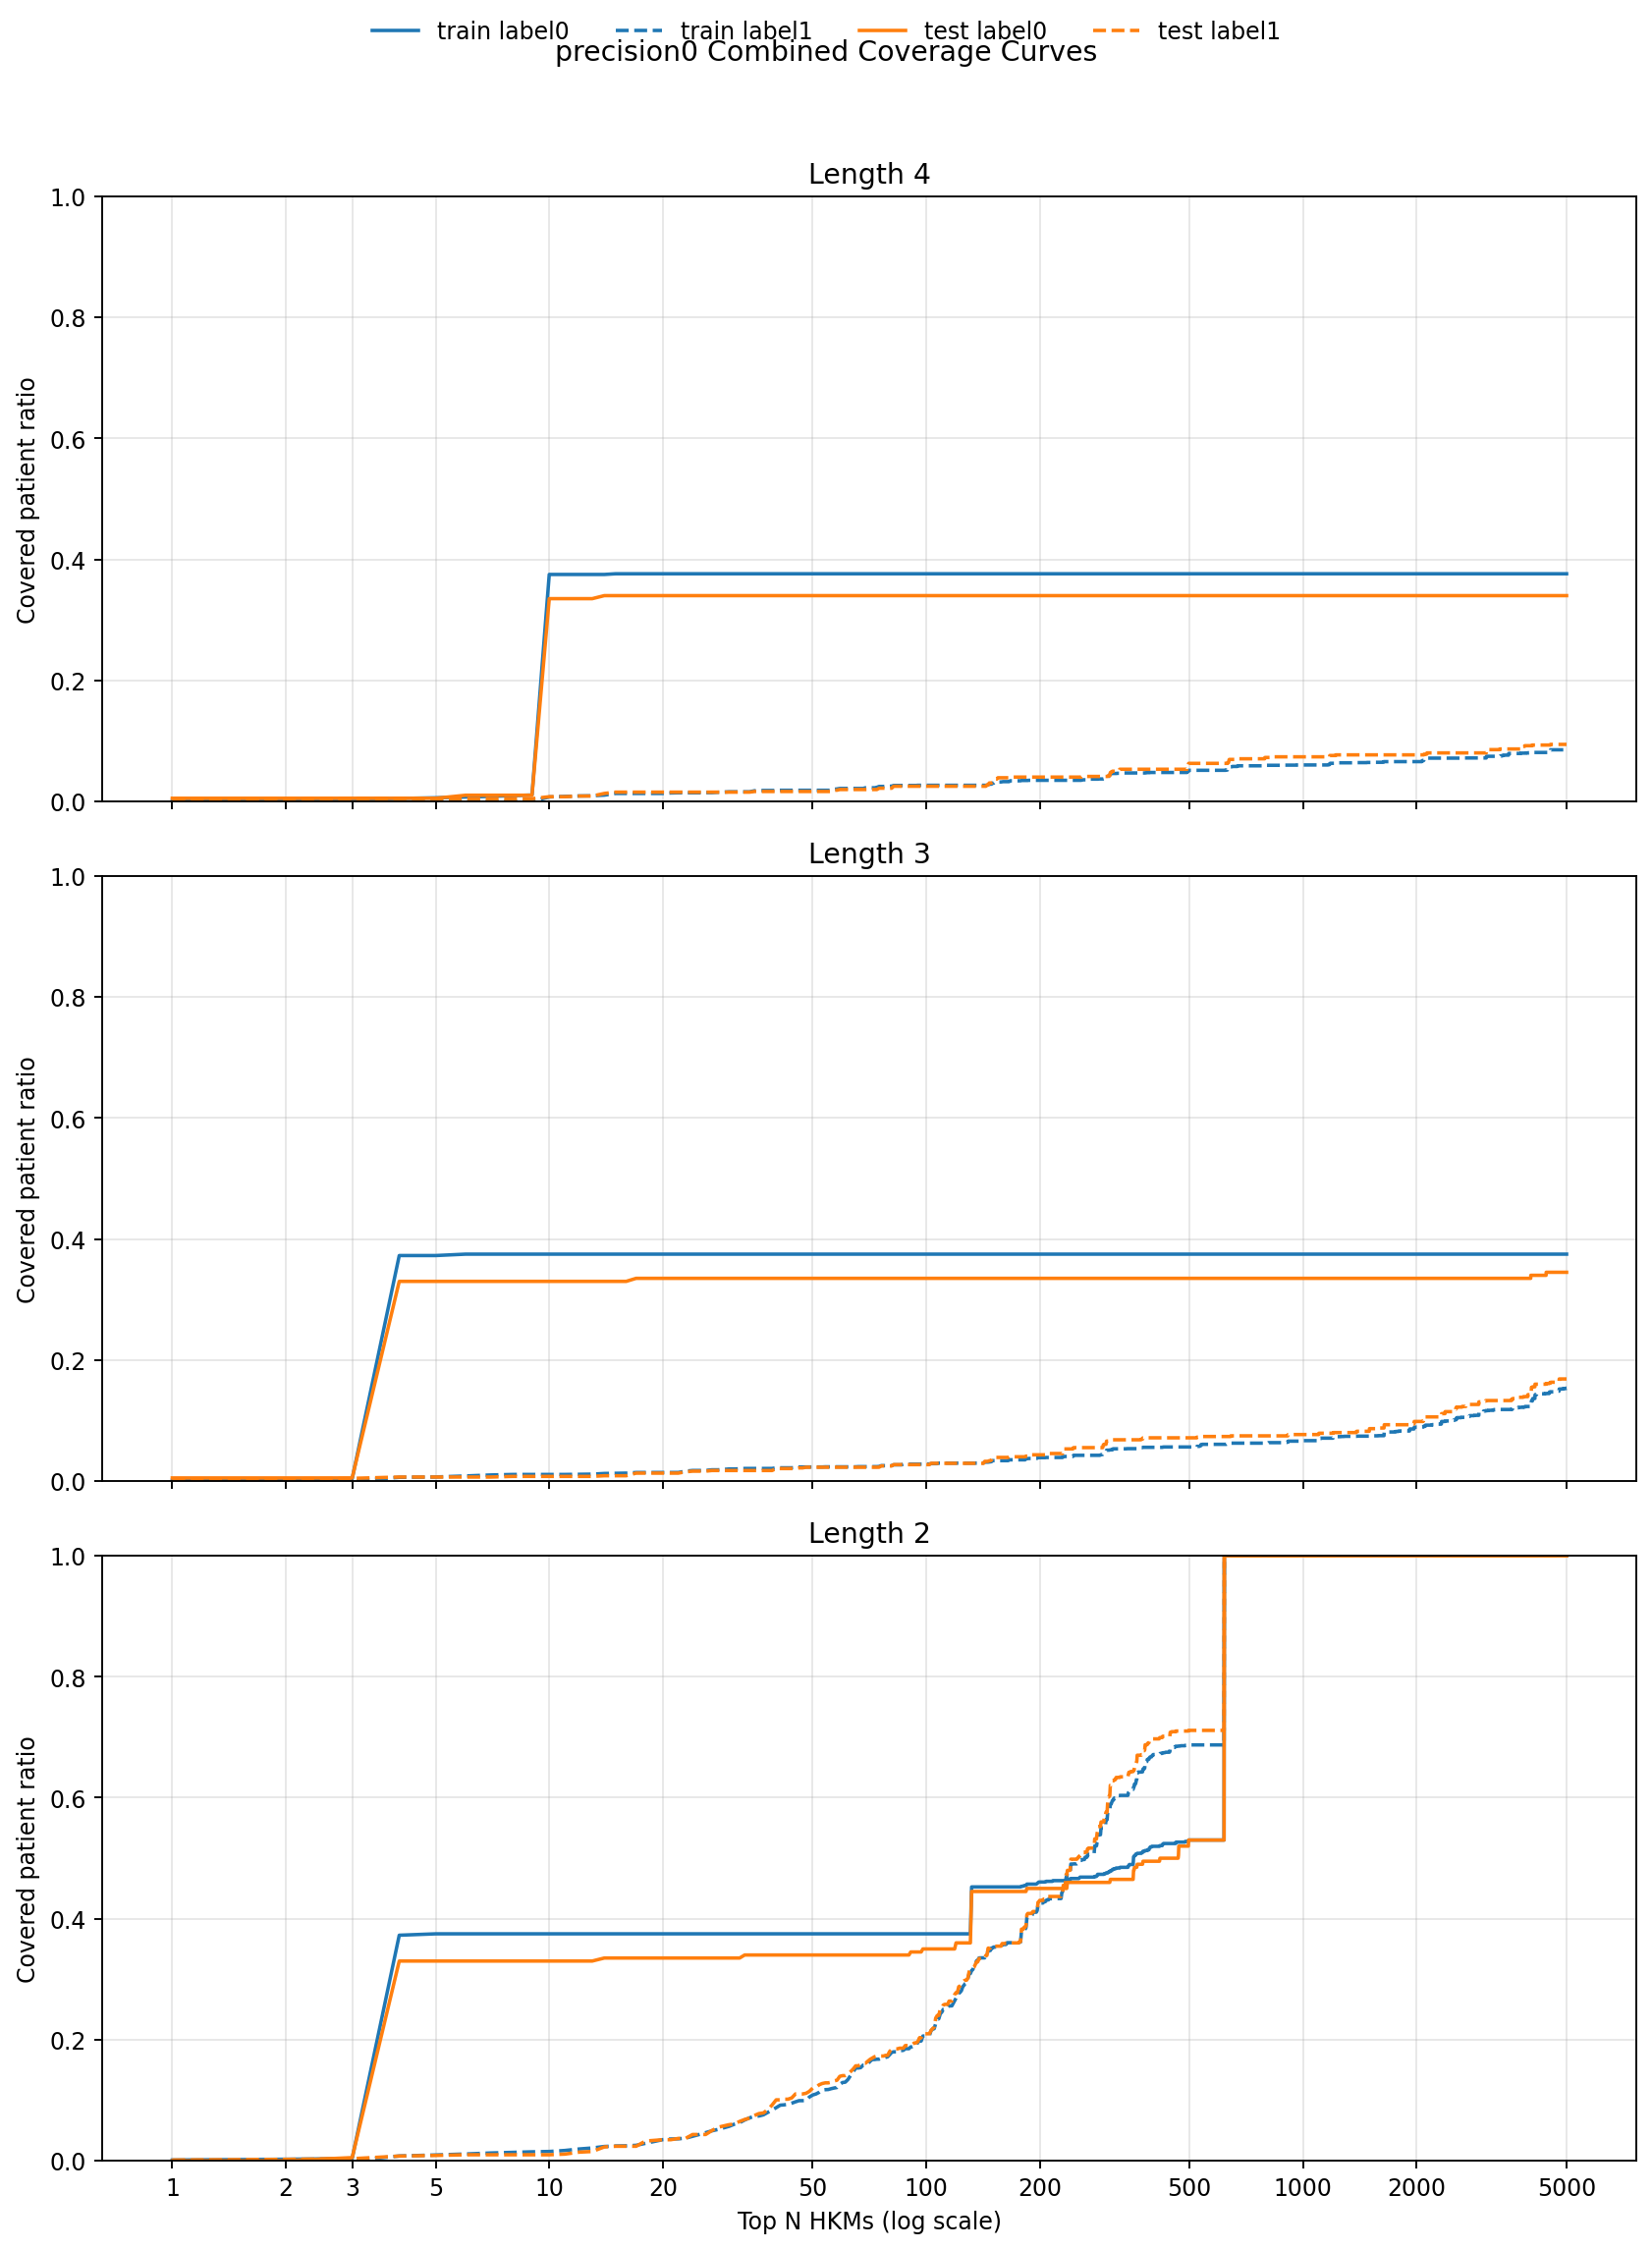

In [11]:
plot_context = load_plot_context_from_output_dir(PLOT_OUTPUT_DIR)
curve_suffix = 'all' if plot_context['curve_top_n'] is None else f"top{plot_context['curve_top_n']}"
plot_path = all_logic_combined_figure_path(plot_context['combined_curve_dir'], curve_suffix)
display(Image(filename=str(plot_path)))


Deprecated duplicate display cell kept empty.


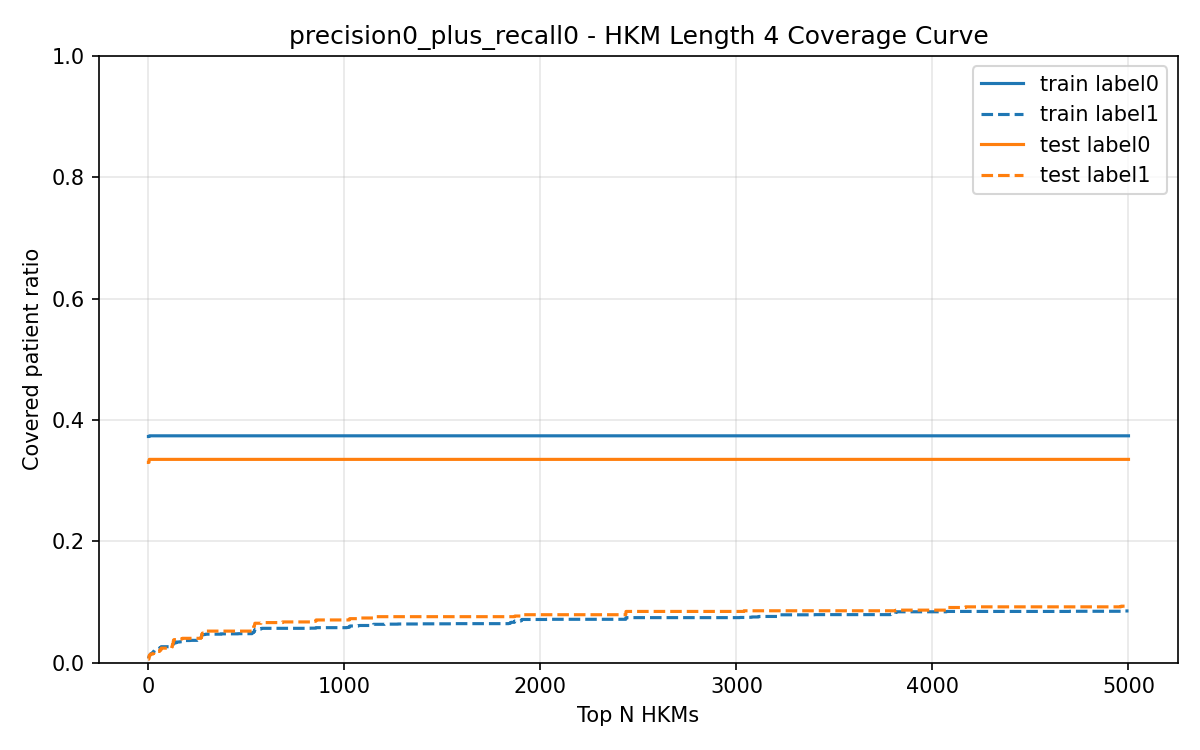

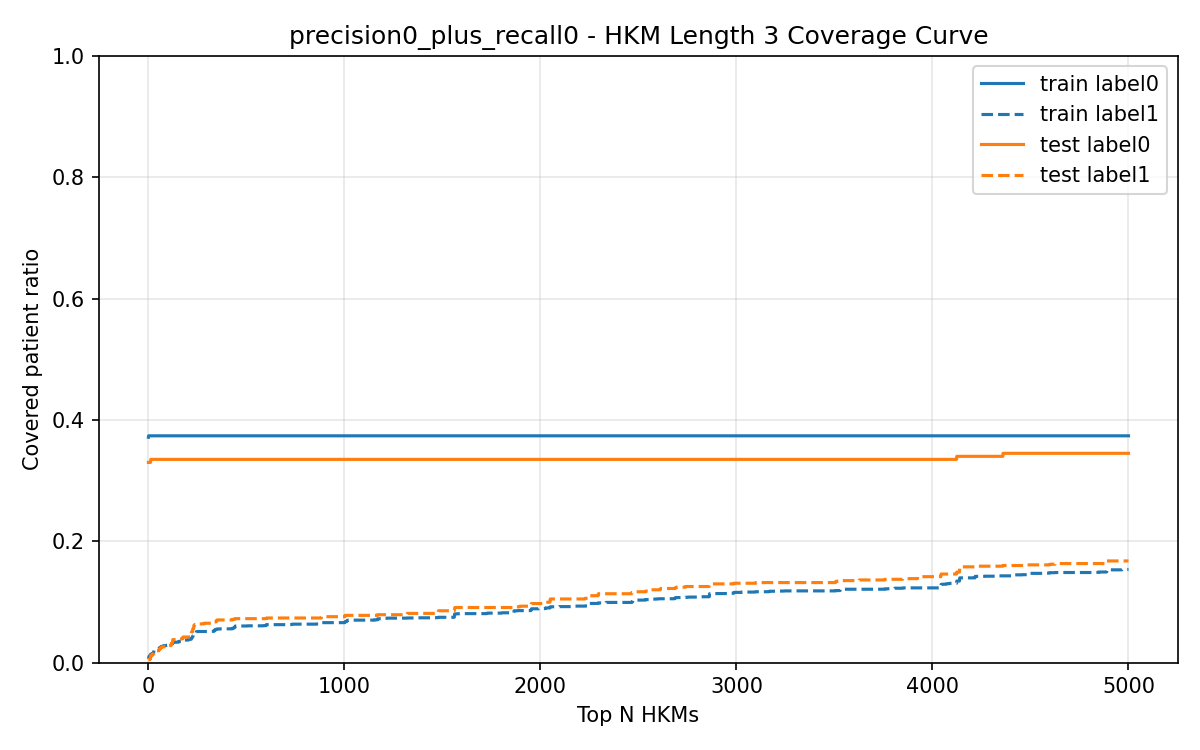

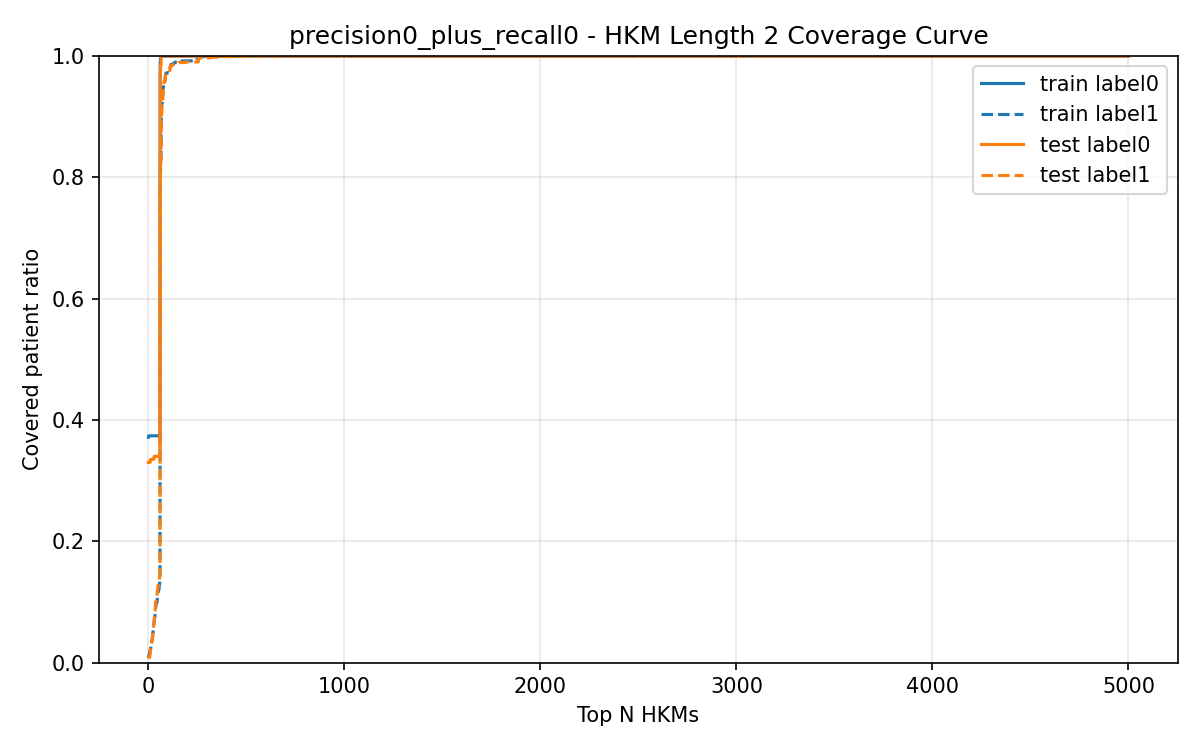

In [22]:
# Duplicate image display removed; use the combined 6-subplot image cell above.
None
